# Human in the Loop

## Definition

Human-in-the-loop is a workflow pattern where a human can **inspect the graph execution, provide feedback, approve actions, or modify the state** before the workflow continues.

In LangGraph, this allows humans to interact with an agent at specific points during execution instead of allowing the entire workflow to run automatically.

## How Human-in-the-Loop Works with LangGraph

1. **Run the Graph:** The LangGraph workflow starts executing and processes the input.
2. **Stream the Execution:** Graph outputs can be streamed so that the human can observe the workflow as it runs.
3. **Interrupt the Workflow:** The graph can pause at a defined point and wait for human interaction.
4. **Inspect the State:** The current graph state can be retrieved and reviewed by the human.
5. **Provide Human Feedback:** The human can approve an action, provide feedback, or modify the state.
6. **Update the State:** LangGraph provides mechanisms to update the graph state with the human's input.
7. **Resume the Workflow:** The graph continues execution using the updated or approved state.
8. **Repeat if Required:** The workflow can pause again for additional human intervention.

## Benefits of Human in the Loop

- **Human Approval:** Allows humans to review and approve actions before they are executed.
- **Debugging:** Makes it easier to inspect and rewind graph execution to identify and resolve issues.
- **State Editing:** Allows humans to modify the graph state during execution.
- **Better Control:** Provides greater control over automated agent workflows.
- **Error Correction:** Human feedback can be used to correct intermediate results.
- **Interactive Workflows:** Enables users to interact with the agent while the workflow is running.
- **Flexible Execution:** Allows the workflow to be paused, updated, and resumed as needed.

## Problem Statement

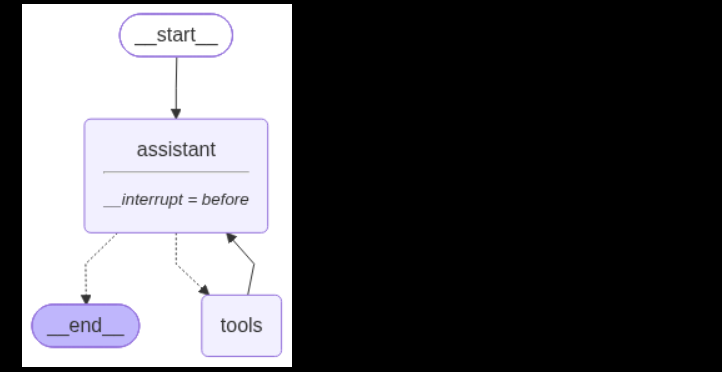

## Solution

### Setting Up the Chat Model

In [1]:
### Importing Required Libraries
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq

# os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

llm = ChatGroq(
    model="qwen/qwen3.8-27b",
    max_tokens=500
)

result=llm.invoke("Hello")
result

AIMessage(content='Hello! How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 13, 'total_tokens': 23, 'completion_time': 0.019249094, 'completion_tokens_details': None, 'prompt_time': 0.000834297, 'prompt_tokens_details': None, 'queue_time': 0.474459166, 'total_time': 0.020083391}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_a1293f40b5', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a10219-14af-7841-9fb8-22ed6af57df7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 10, 'total_tokens': 23})

### Defining the Tools

In [2]:
### Creating the multiply Tool
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b


### Creating the add Tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b


### Creating the divide Tool
def divide(a: int, b: int) -> float:
    """Divide a by b.

    Args:
        a: first int
        b: second int
    """
    return a / b


### Creating the Tools List
tools=[add,multiply,divide]
tools

[<function __main__.add(a: int, b: int) -> int>,
 <function __main__.multiply(a: int, b: int) -> int>,
 <function __main__.divide(a: int, b: int) -> float>]

### Binding Tools with the Chat Model

In [3]:
llm_with_tools=llm.bind_tools(tools)
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.5', 'langchain': '1.4.2'}}, client=<groq.resources.chat.completions.Completions object at 0x000002134140A870>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000021341605190>, model_name='qwen/qwen3.8-27b', model_kwargs={}, groq_api_key=SecretStr('**********'), max_tokens=500), kwargs={'tools': [{'type': 'function', 'function': {'name': 'add', 'description': 'Adds a and b.', 'parameters': {'properties': {'a': {'description': 'first int', 'type': 'integer'}, 'b': {'description': 'second int', 'type': 'integer'}}, 'required': ['a', 'b'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'multiply', 'description': 'Multiply a and b.', 'parameters': {'properties': {'a': {'description': 'first int', 'type': 'integer'}, 'b': {'description': 'second int', 'type': 'integer'}}, 'required': ['a', 'b'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'divide',

### Building the Human-in-the-Loop Workflow

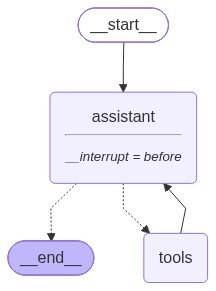

In [4]:
### Importing LangGraph Components
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode
from langchain_core.messages import HumanMessage,SystemMessage

### Defining the System Message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

### Defining the Assistant Node
def assistant(state:MessagesState):
    return {"messages":[llm_with_tools.invoke([sys_msg] + state["messages"])]}

### Creating the StateGraph
builder=StateGraph(MessagesState)

### Adding the Graph Nodes
builder.add_node("assistant",assistant)
builder.add_node("tools",ToolNode(tools))

### Adding the Graph Edges
builder.add_edge(START,"assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,

)
builder.add_edge("tools","assistant")

### Creating the Memory Saver
memory=MemorySaver()

### Compiling the Graph with an Interrupt (Human In The Loop)
graph=builder.compile(interrupt_before=["assistant"],checkpointer=memory)

### Visualizing the Workflow
display(Image(graph.get_graph().draw_mermaid_png()))

### Running the Human-in-the-Loop Workflow

#### Creating the Thread Configuration and Providing the Initial Input

In [5]:
thread={"configurable":{"thread_id":"123"}}
initial_input={"messages":HumanMessage(content="Multiply 2 and 3")}

#### Running the Graph Until the First Interruption

In [ ]:
for event in graph.stream(initial_input,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


## Inspecting the Graph State

### Checking the Current Graph State

In [7]:
state=graph.get_state(thread)
state.next

('assistant',)

### Viewing the Graph State History

In [10]:
graph.get_state_history(thread)

<generator object Pregel.get_state_history at 0x0000021342AEC720>

### Inspecting the Current State

In [8]:
state

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='31833873-a83d-4679-8219-3ac06d2cd53b')]}, next=('assistant',), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1bf348-b4e7-635a-8000-d975e1bcef39'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-10-03T14:13:02.157500+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1bf348-b4ce-61c1-bfff-5ef05fe612bd'}}, tasks=(PregelTask(id='954abe3a-b653-0323-5ac7-47d969743362', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())

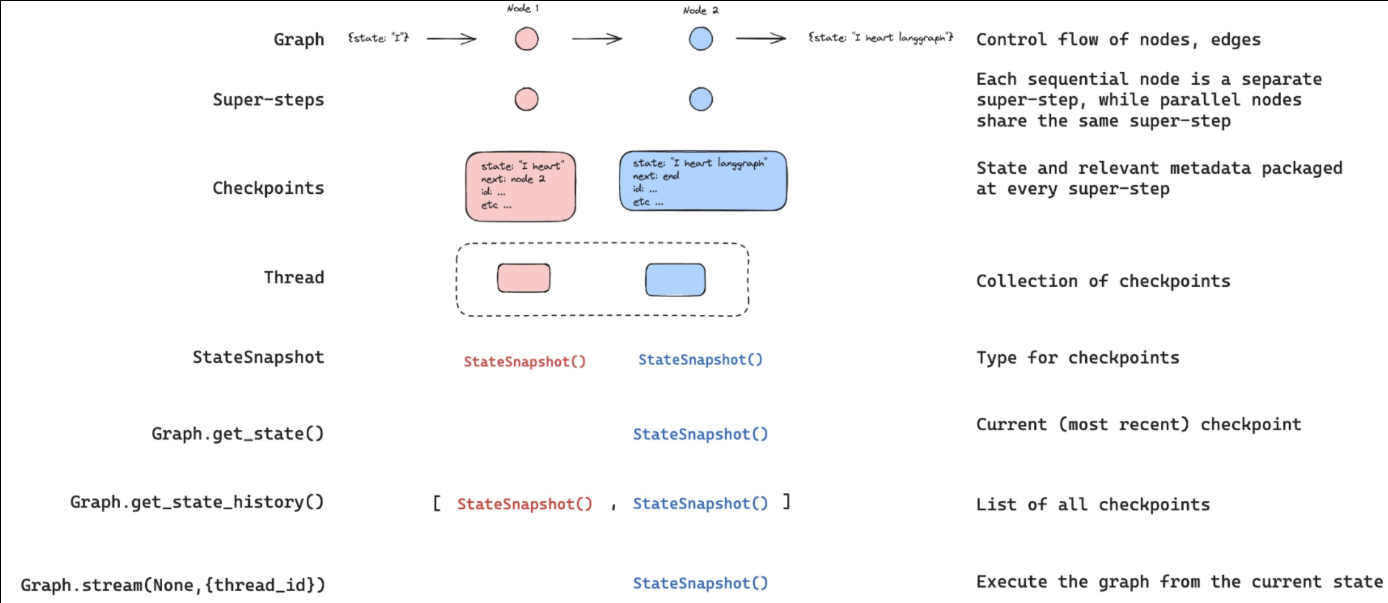

### Resuming the Interrupted Workflow

#### Continue the execution to Assistant

In [11]:
for event in graph.stream(None,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (9c7v253rm)
 Call ID: 9c7v253rm
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


#### Checking the Next Graph Step

In [12]:
state=graph.get_state(thread)
state.next

('assistant',)

#### Continue the execution of Assistant and then end

In [13]:
for event in graph.stream(None,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

2 × 3 = **6**


## Editing Human Feedback in Workflow

### Running the Human-in-the-Loop Workflow

In [14]:
thread={"configurable":{"thread_id":"1"}}
initial_input={"messages":HumanMessage(content="Multiply 2 and 3")}

### Streaming the Graph Execution

In [15]:
for event in graph.stream(initial_input,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


### Checking the Current Graph State

In [16]:
state=graph.get_state(thread)
state.next

('assistant',)

### Updating the Human Feedback

In [17]:
graph.update_state(thread, {"messages":[HumanMessage(content="No, please multiply 16 and 5")]})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1bf38e-f50d-614a-8001-3e8d836b3aa0'}}

### Viewing the Updated State

In [18]:
new_state=graph.get_state(thread).values

for m in new_state["messages"]:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================ Human Message =================================

No, please multiply 16 and 5


### Resuming the Workflow

In [19]:
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

No, please multiply 16 and 5
================================== Ai Message ==================================
Tool Calls:
  multiply (d0e3kj4ve)
 Call ID: d0e3kj4ve
  Args:
    a: 16
    b: 5
================================= Tool Message =================================
Name: multiply

80


In [20]:
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

80
================================== Ai Message ==================================

The result of multiplying 16 and 5 is **80**.


## Runtime Human Feedback in Workflow

### Building the Runtime Feedback Graph

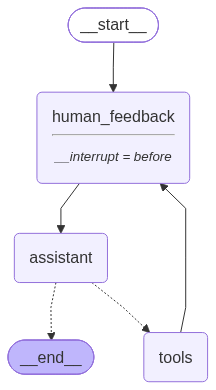

In [22]:
### Defining the System Message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

### Defining the Human Feedback Node
def human_feedback(state:MessagesState):
    pass

### Defining the Assistant Node
def assistant(state:MessagesState):
    return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

### Creating the StateGraph
builder = StateGraph(MessagesState)

### Adding the Graph Nodes
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))
builder.add_node("human_feedback", human_feedback)

### Adding the Graph Edges
builder.add_edge(START,"human_feedback")
builder.add_edge("human_feedback","assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools","human_feedback")

### Creating the Memory Saver
memory=MemorySaver()

### Compiling the Graph with an Interrupt (Human In The Loop)
graph=builder.compile(interrupt_before=["human_feedback"],checkpointer=memory)

### Visualizing the Workflow
display(Image(graph.get_graph().draw_mermaid_png()))

### Running the Runtime Human Feedback Workflow

#### Creating the Thread Configuration and Providing the Initial Input

In [23]:
thread = {"configurable": {"thread_id": "5"}}
initial_input = {"messages": "Multiply 2 and 3"}

#### Running the Graph Until the First Interruption

In [ ]:
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


#### Getting Runtime Human Feedback

In [25]:
user_input=input("Tell me how you want to update the state:")
graph.update_state(thread,{"messages":user_input},as_node="human_feedback")

{'configurable': {'thread_id': '5',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1bf3c1-b5bf-6090-8001-bdcf7934b005'}}

#### Resuming the Graph Execution

In [26]:
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================


================================== Ai Message ==================================
Tool Calls:
  multiply (v2xd514mt)
 Call ID: v2xd514mt
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


#### Continuing the Graph Execution

In [27]:
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The result of multiplying 2 and 3 is **6**.
